<a href="https://colab.research.google.com/github/Lamiya-56/Hourly-and-Daily-Demand-Pattern-Analysis-for-NYC-Taxi-Trips/blob/main/Hourly_and_Daily_Demand_Pattern_Analysis_for_NYC_Taxi_Trips.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import pandas as pd
df = pd.read_csv('/content/NYC.csv.zip')
df.head(10)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435
5,id0801584,2,2016-01-30 22:01:40,2016-01-30 22:09:03,6,-73.982857,40.742195,-73.992081,40.749184,N,443
6,id1813257,1,2016-06-17 22:34:59,2016-06-17 22:40:40,4,-73.969017,40.757839,-73.957405,40.765896,N,341
7,id1324603,2,2016-05-21 07:54:58,2016-05-21 08:20:49,1,-73.969276,40.797779,-73.922470,40.760559,N,1551
8,id1301050,1,2016-05-27 23:12:23,2016-05-27 23:16:38,1,-73.999481,40.738400,-73.985786,40.732815,N,255
9,id0012891,2,2016-03-10 21:45:01,2016-03-10 22:05:26,1,-73.981049,40.744339,-73.973000,40.789989,N,1225


In [54]:
df.shape

(1458644, 11)

In [55]:
df.isnull().sum()

,0
id,0
vendor_id,0
pickup_datetime,0
dropoff_datetime,0
passenger_count,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
store_and_fwd_flag,0


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [57]:
df.duplicated().sum()

np.int64(0)

In [58]:
df['pickup_datetime']=pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime']=pd.to_datetime(df['dropoff_datetime'])
df['trip_duration_min']=df['trip_duration']/60
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 12 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  object        
 1   vendor_id           1458644 non-null  int64         
 2   pickup_datetime     1458644 non-null  datetime64[ns]
 3   dropoff_datetime    1458644 non-null  datetime64[ns]
 4   passenger_count     1458644 non-null  int64         
 5   pickup_longitude    1458644 non-null  float64       
 6   pickup_latitude     1458644 non-null  float64       
 7   dropoff_longitude   1458644 non-null  float64       
 8   dropoff_latitude    1458644 non-null  float64       
 9   store_and_fwd_flag  1458644 non-null  object        
 10  trip_duration       1458644 non-null  int64         
 11  trip_duration_min   1458644 non-null  float64       
dtypes: datetime64[ns](2), float64(5), int64(3), object(2)
memory usage: 13

In [59]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,trip_duration_min
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,7.583333
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,11.050000
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,35.400000
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,7.150000
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,7.250000


In [60]:
# Outlier-lər: 24 saatdan uzun səfərlər

df[df['trip_duration_min']>1440]

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,trip_duration_min
355003,id1864733,1,2016-01-05 00:19:42,2016-01-27 11:08:38,1,-73.789650,40.643559,-73.956810,40.773087,N,1939736,32328.933333
680594,id0369307,1,2016-02-13 22:38:00,2016-03-08 15:57:38,2,-73.921677,40.735252,-73.984749,40.759979,N,2049578,34159.633333
924150,id1325766,1,2016-01-05 06:14:15,2016-01-31 01:01:07,1,-73.983788,40.742325,-73.985489,40.727676,N,2227612,37126.866667
978383,id0053347,1,2016-02-13 22:46:52,2016-03-25 18:18:14,1,-73.783905,40.648632,-73.978271,40.750202,N,3526282,58771.366667


In [61]:
# Outlier-lərin filtr edilməsi (24 saatdan az və 1 dəqiqədən çox olanlar)
df = df[(df['trip_duration_min'] > 1) & (df['trip_duration_min'] < 1440)].copy()
df

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,trip_duration_min
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,7.583333
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,11.050000
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,35.400000
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,7.150000
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,7.250000
...,...,...,...,...,...,...,...,...,...,...,...,...
1458639,id2376096,2,2016-04-08 13:31:04,2016-04-08 13:44:02,4,-73.982201,40.745522,-73.994911,40.740170,N,778,12.966667
1458640,id1049543,1,2016-01-10 07:35:15,2016-01-10 07:46:10,1,-74.000946,40.747379,-73.970184,40.796547,N,655,10.916667
1458641,id2304944,2,2016-04-22 06:57:41,2016-04-22 07:10:25,1,-73.959129,40.768799,-74.004433,40.707371,N,764,12.733333
1458642,id2714485,1,2016-01-05 15:56:26,2016-01-05 16:02:39,1,-73.982079,40.749062,-73.974632,40.757107,N,373,6.216667


In [62]:
#Ortalama trip duration;median

print(f"Ortalama trip duration : {df['trip_duration_min'].mean()}")
print(f"Median : {df['trip_duration_min'].median()}")

Ortalama trip duration : 15.973553558738539
Median : 11.1


In [63]:
df['hour']=df['pickup_datetime'].dt.hour
df['day_of_week']=df['pickup_datetime'].dt.day_name()
df['month']=df['pickup_datetime'].dt.month_name()

In [64]:
df

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,trip_duration_min,hour,day_of_week,month
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,7.583333,17,Monday,March
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,11.050000,0,Sunday,June
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,35.400000,11,Tuesday,January
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,7.150000,19,Wednesday,April
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,7.250000,13,Saturday,March
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458639,id2376096,2,2016-04-08 13:31:04,2016-04-08 13:44:02,4,-73.982201,40.745522,-73.994911,40.740170,N,778,12.966667,13,Friday,April
1458640,id1049543,1,2016-01-10 07:35:15,2016-01-10 07:46:10,1,-74.000946,40.747379,-73.970184,40.796547,N,655,10.916667,7,Sunday,January
1458641,id2304944,2,2016-04-22 06:57:41,2016-04-22 07:10:25,1,-73.959129,40.768799,-74.004433,40.707371,N,764,12.733333,6,Friday,April
1458642,id2714485,1,2016-01-05 15:56:26,2016-01-05 16:02:39,1,-73.982079,40.749062,-73.974632,40.757107,N,373,6.216667,15,Tuesday,January


In [65]:
# Ən yüksək trafik saatı
hourly_traffic = df.groupby('hour').size().sort_values(ascending=False)
hourly_traffic.head(2)

,0
hour,
18,90152
19,89860


In [66]:
# ən sakit trafik saatı
hourly_traffic.tail(1)

,0
hour,
5,14789


Ən yüksək trafik saatı: 18:00–19:00 (axşam rush hour); ən sakit: 05:00

In [67]:
#Günlərə görə trafik
day_traffic = df.groupby('day_of_week').size().sort_values(ascending=False)
day_traffic

,0
day_of_week,
Friday,222199
Saturday,219571
Thursday,217233
Wednesday,209007
Tuesday,201587
Sunday,194006
Monday,186260


Bazar ertəsi ən az səfər olan gündür, Cümə ən çox

In [68]:
#Aylıq ortalama müddət
monthly_duration = df.groupby('month')['trip_duration_min'].mean().round()
monthly_duration

,trip_duration_min
month,
April,16.0
February,15.0
January,15.0
June,17.0
March,16.0
May,17.0


Aprel ayı ən yüksək ortalama trip duration göstərir (yağış mövsümü)

In [69]:
vendor_counts = (df['vendor_id'].value_counts(normalize=True) * 100).round()
vendor_counts

,proportion
vendor_id,
2,54.0
1,46.0


<Axes: title={'center': 'Hourly Average Trip Duration'}, xlabel='hour'>

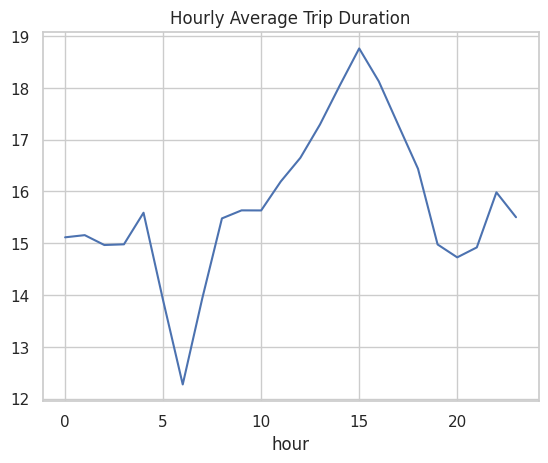

In [70]:
# Calculate average trip duration by hour of day
hourly_avg_duration = df.groupby('hour')['trip_duration_min'].mean()

# Vizuallaşdırma
hourly_avg_duration.plot(kind='line', title='Hourly Average Trip Duration')

Qrafik göstərir ki, səfər müddəti saat 15:00-da pik həddə (təxminən 19 dəqiqə) çatır. Bu, günorta saatlarında trafikin ən sıx olduğu vaxtdır.

#Visualizations

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

##Line chart of trips by hour

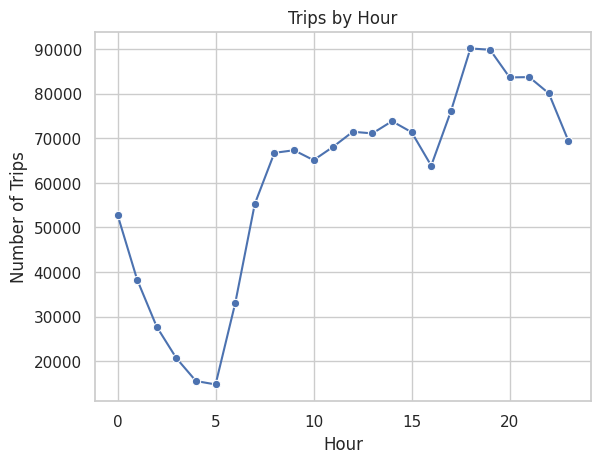

In [72]:
df['hour'] = df['pickup_datetime'].dt.hour

trips_by_hour = df.groupby('hour').size().reset_index(name='trips')

plt.figure()
sns.lineplot(data=trips_by_hour, x='hour', y='trips', marker='o')
plt.title('Trips by Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Trips')
plt.show()

In [73]:
trips_by_hour.sort_values('trips')

,hour,trips
5,5,14789
4,4,15558
3,3,20685
2,2,27715
6,6,32962
1,1,38292
0,0,52841
7,7,55268
16,16,63865
10,10,65100


Günün ən yüksək tələbat nöqtəsi saat 18:00 - 19:00 aralığıdır (təxminən 90,000 səfər). Bu, iş gününün bitməsi və insanların evə və ya sosial görüşlərə getməsi ilə birbaşa bağlıdır.

Saat 05:00-dan başlayaraq saat 08:00 - 09:00-a qədər kəskin bir artım var. Bu isə səhər işə getmə vaxtını təmsil edir.

Tələbat gecə saat 22:00-dan sonra azalmağa başlayır və günün ən aşağı nöqtəsinə (təxminən 15,000 səfər) saat 05:00-da çatır.

##Bar chart of trips by weekday

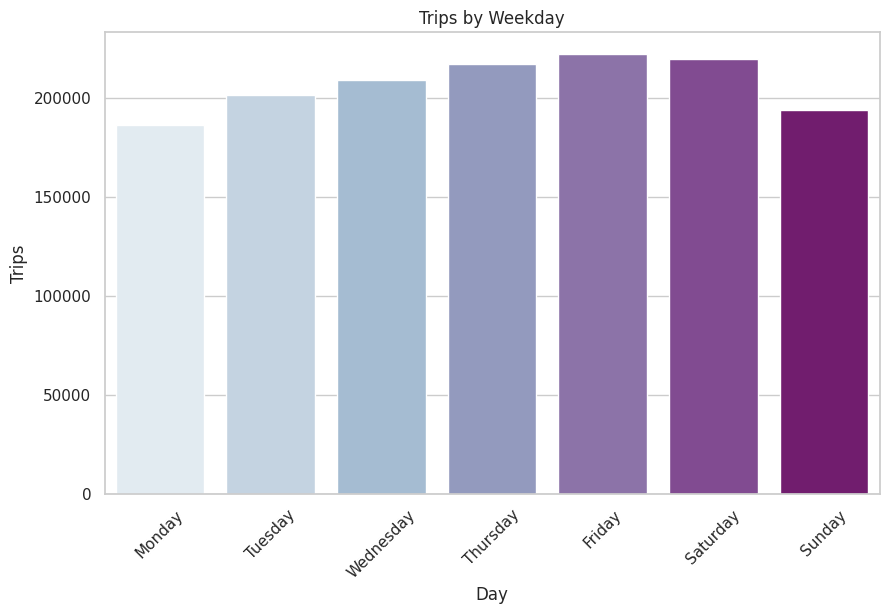

In [85]:
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_counts = df['day_of_week'].value_counts().reindex(days_order)

plt.figure(figsize=(10, 6))

sns.barplot(x=weekly_counts.index, y=weekly_counts.values, hue=weekly_counts.index, palette='BuPu')
plt.title('Trips by Weekday')
plt.xlabel('Day')
plt.ylabel('Trips')
plt.xticks(rotation=45)
plt.show()

Cümə günü həftənin "pik" günüdür. Bu, həm iş həftəsinin sonu, həm də sosial aktivliklərin artması ilə bağlı ola bilər.

Bazar ertəsindən Cümə axşamına qədər olan artım, həftə irəlilədikcə şəhər daxili hərəkətliliyin intensivləşdiyini göstərir.

##Histogram of trip duration

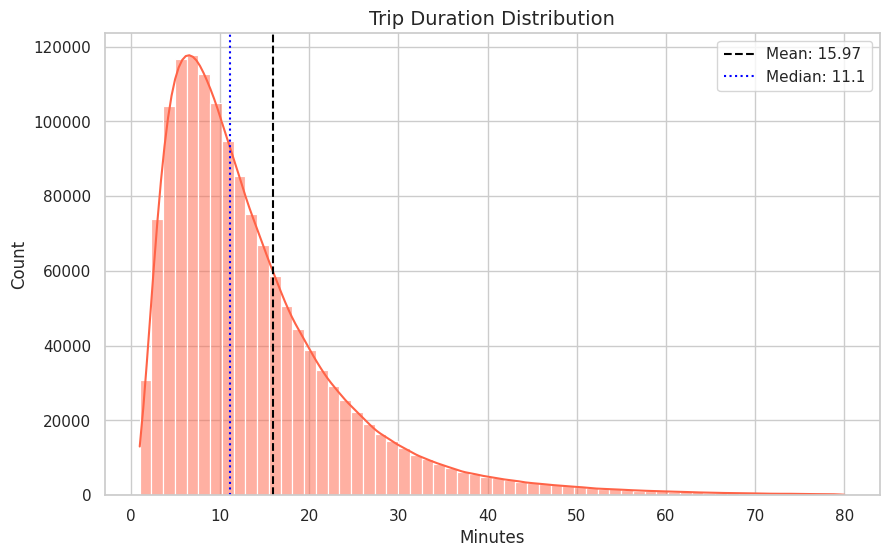

In [75]:
plt.figure(figsize=(10, 6))

sns.histplot(df[df['trip_duration_min'] < 80]['trip_duration_min'], bins=60, kde=True, color='tomato', alpha=0.5)
# kde=True: dalğalı xətti əlavə edir

# Mean, median üçün xəttləri çəkmək
plt.axvline(df['trip_duration_min'].mean(), color='black', linestyle='--', label='Mean: 15.97')
plt.axvline(df['trip_duration_min'].median(), color='blue', linestyle=':', label='Median: 11.1')

plt.title('Trip Duration Distribution', fontsize=14)
plt.xlabel('Minutes')
plt.ylabel('Count')
plt.legend()
plt.show()

Median dəyərin (11 dəqiqə) orta dəyərdən (16 dəqiqə) aşağı olması, datanın right-skewed olduğunu göstərir.

Taksi istifadəçilərinin əksəriyyəti 5-15 dəqiqəlik qısa və orta məsafəli səfərlərə üstünlük verir.

Orta dəyərin medianı üstələməsi, tıxac və ya uzun məsafəli nadir səfərlərin ümumi ortalamaya ciddi təsir etdiyini sübut edir.

##Monthly trend bar

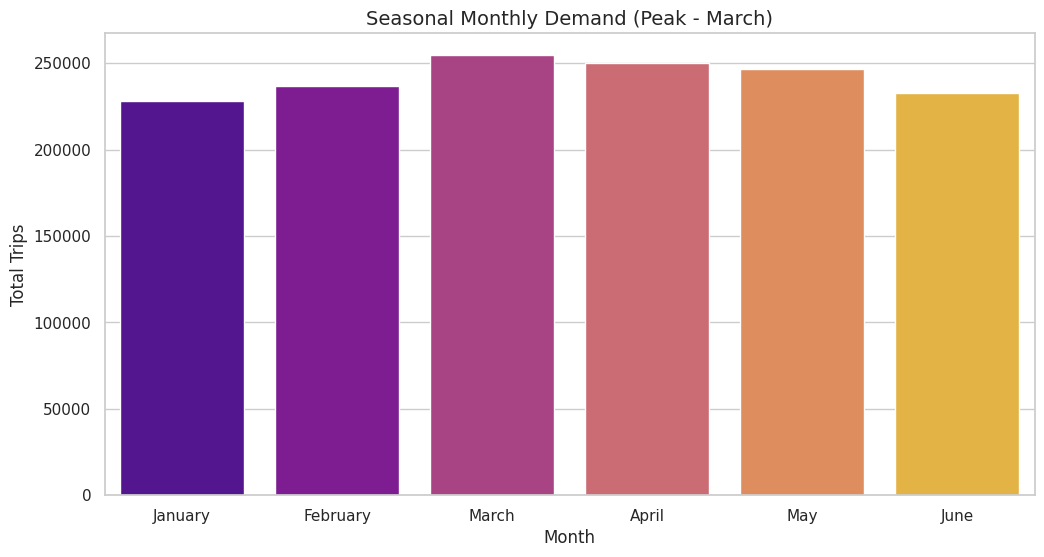

In [76]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 2. Ayların düzgün ardıcıllığı təyin edilir
months_order = ['January', 'February', 'March', 'April', 'May', 'June']

# 3. Yuxarıdakı sıraya görə düzülür
monthly_data = df['month'].value_counts().reindex(months_order)

sns.barplot(x=monthly_data.index, y=monthly_data, hue=monthly_data.index, palette='plasma')

plt.title('Seasonal Monthly Demand (Peak - March)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Trips')
plt.show()

Yanvar ayında səfər sayı təxminən 225,000 civarında olduğu halda, Mart ayında bu rəqəm 250,000-i keçir. Bu, cəmi iki ay ərzində təxminən 25,000 - 30,000 əlavə səfər deməkdir.

Bu, təxminən 10-12%-lik bir artım deməkdir və havaların istiləşməsi, şəhərdə turistik/sosial hərəkətliliyin artması ilə əlaqələndirilə bilər.

In [77]:
df['month'].value_counts().sort_values()

,count
month,
January,228377
June,232881
February,236903
May,246960
April,250055
March,254687


##Heatmap

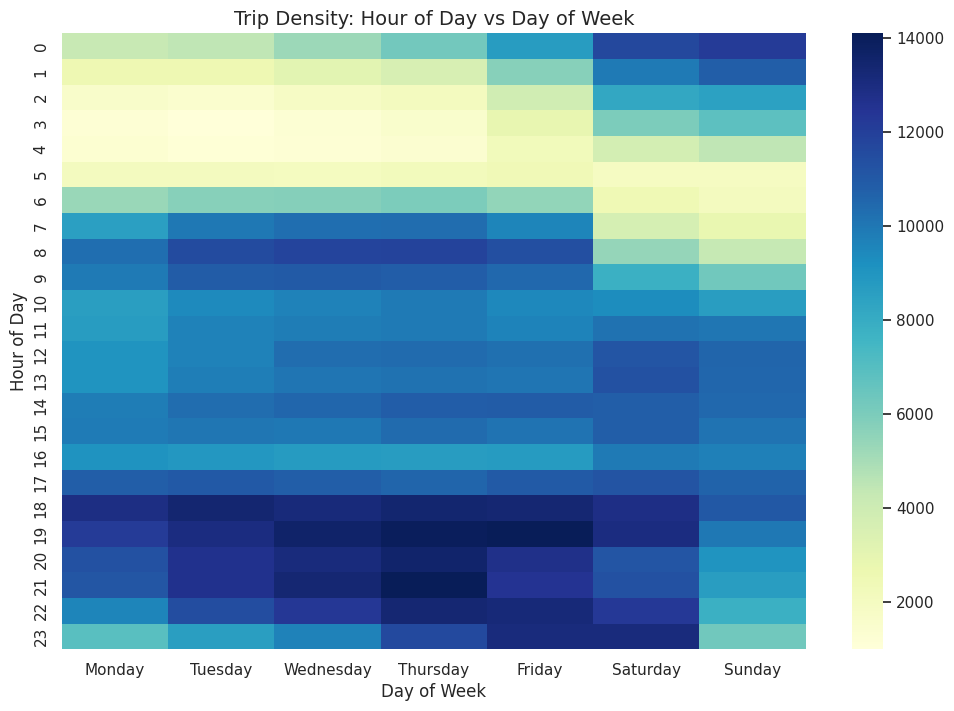

In [78]:
heatmap_data = df.groupby(['hour', 'day_of_week']).size().unstack()
heatmap_data = heatmap_data.reindex(columns=days_order)

# 2. Heatmap-in çəkilməsi
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=False)

plt.title('Trip Density: Hour of Day vs Day of Week', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Hour of Day')
plt.show()

Şənbə və Bazar günləri saat 00:00 - 02:00 arası olan tələbat, həftə içi eyni saatlarla müqayisədə qat-qat yüksəkdir. İnsanlar əyləncədən evə qayıtmaq üçün taksiyə üstünlük verirlər.

Bazar ertəsindən Cüməyə qədər səhər saat 08:00 - 09:00 aralığında üfüqi bir tündləşmə var. Bu, insanların işə və ya dərsə getmək üçün yaratdığı tələbatdır.
Saat 18:00 - 20:00 arası bütün həftə boyu (Bazar günü istisna olmaqla) ən yüksək sıxlıq müşahidə olunur. Xüsusilə Cümə axşamı və Cümə günləri bu zona ən tünd (14,000-ə yaxın) həddinə çatır.

Həftənin hansı günü olmasından asılı olmayaraq, səhər saat 04:00 - 05:00 aralığı (açıq sarı rəng) şəhərdə ən aşağı tələbatın müşahidə edildiyi zamandır.

#INSIGHTS

18:00–19:00 aralığında tələbat ən yüksək həddə çatdığı üçün, sürücülərin növbə dəyişikliyini bu saatlara salmaqdan qaçınmaq lazımdır. Bütün mövcud avtomobillər həmin saatda xətdə olmalıdır.

Cümə günü həftənin ən çox səfər edilən günü olduğu üçün "Cümə-Şənbə" keçidində növbə sayını artırmaq və sürücülərə həvəsləndirici bonuslar təyin etmək gəliri maksimallaşdıra bilər.

Aprel ayı ən uzun səfər müddətlərini göstərdiyi üçün avtomobillər(əyləc sistemi, təkərlər və silənlər və s.) mart ayında kütləvi texniki baxışdan keçirilməlidir.

Səhər saat 05:00-da tələbat ən aşağı səviyyədədir. Bu saatlar avtomobillərin yanacaq doldurulması, təmizlənməsi və proqram təminatı yeniləmələri üçün ən uyğun vaxtdır.